In [1]:
import numpy as np
import plotly.graph_objects as go

t = np.linspace(0, 2, 100)
x = 10 * t
y = 2 * np.sin(t * 3)
z = 1.2 + 5 * np.sin(t) - 4.9 * t**2

fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=4)
)])
fig.update_layout(scene=dict(
    xaxis_title='X (m)',
    yaxis_title='Y (m)',
    zaxis_title='Z (m)'
))
fig.show()


In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from math import cos, sin, radians, sqrt

# ----- 尺寸常數 -----
COURT_LEN = 13.4
COURT_W   = 6.1
HALF_W    = COURT_W / 2
NET_X     = 6.7
NET_H     = 1.524

SINGLES_W = 5.18
SINGLES_HALF_W = SINGLES_W / 2  # 2.59 m

SHORT_SERVICE_FROM_NET = 1.98
SHORT_NEAR  = NET_X - SHORT_SERVICE_FROM_NET  # 4.72 m
SHORT_FAR   = NET_X + SHORT_SERVICE_FROM_NET  # 8.68 m

DOUBLES_LONG_FROM_BACK = 0.76
LONG_NEAR = DOUBLES_LONG_FROM_BACK            # 0.76 m
LONG_FAR  = COURT_LEN - DOUBLES_LONG_FROM_BACK# 12.64 m


# ========= 1) 物理模擬：用重力 + 二次阻力（|v|v），Euler 積分 =========
def simulate_trajectory(speed_mps=23.0, yaw_deg=6.0, pitch_deg=20.0,
                        drag_k=0.08, release_height=1.2,
                        dt=0.01, max_t=4.0):
    """
    回傳：
      points: ndarray (N,7) = [x,y,z,vx,vy,vz,t]
      apex:   最高點 dict（含 x,y,z,t）
      cross_net: 過網點 dict（含 x,y,z,t, clearance），可能為 None
      landing: 落地點 dict（含 x,y, z=0, t），可能為 None
    """
    g = 9.81
    yaw   = radians(yaw_deg)
    pitch = radians(pitch_deg)

    # 初速分解
    vx = speed_mps * cos(pitch) * cos(yaw)
    vy = speed_mps * cos(pitch) * sin(yaw)
    vz = speed_mps * sin(pitch)

    x, y, z = 0.0, 0.0, release_height
    t = 0.0

    pts = []
    apex = {"x": x, "y": y, "z": z, "t": t}
    cross_net = None

    prev = None  # 前一個步點（用來檢查穿越）
    landing = None
    while t <= max_t and z >= 0.0:
        pts.append((x, y, z, vx, vy, vz, t))
        if z > apex["z"]:
            apex = {"x": x, "y": y, "z": z, "t": t}

        prev = (x, y, z, vx, vy, vz, t)

        # 阻力 ~ -k |v| v
        vmag = sqrt(vx*vx + vy*vy + vz*vz)
        ax = -drag_k * vmag * vx
        ay = -drag_k * vmag * vy
        az = -g - drag_k * vmag * vz

        # Euler 積分
        vx += ax * dt
        vy += ay * dt
        vz += az * dt
        x  += vx * dt
        y  += vy * dt
        z  += vz * dt
        t  += dt
        
        def lerp(a, b, w):  # 線性內插
            return a + w*(b - a)

        w_net = None
        if (prev[0] - NET_X) * (x - NET_X) <= 0 and x != prev[0]:
            w_net = (NET_X - prev[0]) / (x - prev[0])     # 0~1

        w_land = None
        if prev[2] >= 0.0 and z < 0.0 and z != prev[2]:
            w_land = (0.0 - prev[2]) / (z - prev[2])      # 0~1

        # 僅接受 0<=w<=1
        if w_net is not None and not (0.0 <= w_net <= 1.0):
            w_net = None
        if w_land is not None and not (0.0 <= w_land <= 1.0):
            w_land = None

        # 先算出交點的各項（若有需要）
        def net_point():
            y_net = lerp(prev[1], y, w_net)
            z_net = lerp(prev[2], z, w_net)
            t_net = lerp(prev[6], t, w_net)
            vx_net = lerp(prev[3], vx, w_net)
            vy_net = lerp(prev[4], vy, w_net)
            vz_net = lerp(prev[5], vz, w_net)
            return y_net, z_net, t_net, vx_net, vy_net, vz_net

        def land_point():
            x_land = lerp(prev[0], x, w_land)
            y_land = lerp(prev[1], y, w_land)
            t_land = lerp(prev[6], t, w_land)
            vx_land = lerp(prev[3], vx, w_land)
            vy_land = lerp(prev[4], vy, w_land)
            vz_land = lerp(prev[5], vz, w_land)
            return x_land, y_land, t_land, vx_land, vy_land, vz_land

        # 依先後次序處理事件
        if w_net is not None and w_land is not None:
            # 同一步兩個面都被穿過 → 比較誰先
            if w_land <= w_net:
                # 先落地：只記落地，結束
                x_land, y_land, t_land, vx_land, vy_land, vz_land = land_point()
                landing = {"x": x_land, "y": y_land, "z": 0.0, "t": t_land}
                pts.append((x_land, y_land, 0.0, vx_land, vy_land, vz_land, t_land))
                break
            else:
                # 先到網面：判斷是過網或撞網
                y_net, z_net, t_net, vx_net, vy_net, vz_net = net_point()
                if cross_net is None:
                    cross_net = {"x": NET_X, "y": y_net, "z": z_net,
                                "clearance": z_net - NET_H, "t": t_net}
                # 在網面高度 z_net <= 網高，且 y 在球網寬度內 → 撞網，結束
                if (z_net <= NET_H) and (abs(y_net) <= HALF_W) and (z_net >= 0.0):
                    # 把撞網點補入，讓線停在網面
                    pts.append((NET_X, y_net, z_net, vx_net, vy_net, vz_net, t_net))
                    # 你也可以另外回傳 hit_net 事件（若需要）
                    # hit_net = {"x": NET_X, "y": y_net, "z": z_net, "t": t_net}
                    break
                # 否則只是過網，讓下一步繼續前進

        elif w_land is not None:
            # 只有落地
            x_land, y_land, t_land, vx_land, vy_land, vz_land = land_point()
            landing = {"x": x_land, "y": y_land, "z": 0.0, "t": t_land}
            pts.append((x_land, y_land, 0.0, vx_land, vy_land, vz_land, t_land))
            break

        elif w_net is not None:
            # 只有網面
            y_net, z_net, t_net, vx_net, vy_net, vz_net = net_point()
            if cross_net is None:
                cross_net = {"x": NET_X, "y": y_net, "z": z_net,
                            "clearance": z_net - NET_H, "t": t_net}
            if (z_net <= NET_H) and (abs(y_net) <= HALF_W) and (z_net >= 0.0):
                pts.append((NET_X, y_net, z_net, vx_net, vy_net, vz_net, t_net))
                # hit_net = {"x": NET_X, "y": y_net, "z": z_net, "t": t_net}
                break
        # 兩者皆無 → 繼續迴圈

    points = np.array(pts)
    if landing:
        if not (0 <= landing["x"] <= COURT_LEN and -HALF_W <= landing["y"] <= HALF_W):
            landing = None

    return {"points": points, "apex": apex, "cross_net": cross_net, "landing": landing}


# ========= 2)（你原本的）場地 & 繪圖 =========
def build_figure(sim):
    fig = go.Figure()

    # 球場地板
    fig.add_trace(go.Mesh3d(
        x=[0, COURT_LEN, COURT_LEN, 0],
        y=[-HALF_W, -HALF_W, HALF_W, HALF_W],
        z=[0, 0, 0, 0],
        opacity=0.35, color="seagreen", name="Court",
        i=[0,0], j=[1,2], k=[2,3]
    ))

    def add_line(x1, y1, x2, y2, name, width=6):
        fig.add_trace(go.Scatter3d(
            x=[x1, x2], y=[y1, y2], z=[0, 0],
            mode="lines", line=dict(color="white", width=width), name=name
        ))

    # --- 外框（端線 & 雙打邊線） ---
    add_line(0, -HALF_W, 0,  HALF_W, "baseline (near)")
    add_line(COURT_LEN, -HALF_W, COURT_LEN, HALF_W, "baseline (far)")
    add_line(0, -HALF_W, COURT_LEN, -HALF_W, "sideline (dbl)")
    add_line(0,  HALF_W, COURT_LEN,  HALF_W, "sideline (dbl)")

    # --- 單打邊線 ---
    add_line(0, -SINGLES_HALF_W, COURT_LEN, -SINGLES_HALF_W, "sideline (sgl)")
    add_line(0,  SINGLES_HALF_W, COURT_LEN,  SINGLES_HALF_W, "sideline (sgl)")

    # --- 前發球線（距網 1.98 m）---
    add_line(SHORT_NEAR, -HALF_W, SHORT_NEAR, HALF_W, "short service line (near)")
    add_line(SHORT_FAR,  -HALF_W, SHORT_FAR,  HALF_W, "short service line (far)")

    # --- 中線（從前發球線到各自後方界線）---
    add_line(SHORT_NEAR, 0, 0, 0, "center line (near)")
    add_line(SHORT_FAR, 0, COURT_LEN, 0, "center line (far)")

    # --- 雙打長發球線（距端線 0.76 m）---
    add_line(LONG_NEAR, -HALF_W, LONG_NEAR, HALF_W, "long service line (near)")
    add_line(LONG_FAR,  -HALF_W, LONG_FAR,  HALF_W, "long service line (far)")

    # --- 球網（灰牆）---
    fig.add_trace(go.Mesh3d(
        x=[NET_X, NET_X, NET_X, NET_X],
        y=[-HALF_W, HALF_W, HALF_W, -HALF_W],
        z=[0, 0, NET_H, NET_H],
        opacity=0.5, color="gray", name="Net",
        i=[0,0], j=[1,2], k=[2,3]
    ))

    # ========= 3) 用物理函式取得真實軌跡，取出 x/y/z =========
    pts = sim["points"]                       # ←── [改] 不再用外部 res，改用傳入的 sim
    x, y, z = pts[:,0], pts[:,1], pts[:,2]

    # --- 軌跡線 ---
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z, mode="lines",
        line=dict(color="red", width=6), name="Trajectory"
    ))

    # --- （可選）把過網點與落地點標出來 ---
    if sim["cross_net"] is not None:
        cn = sim["cross_net"]
        fig.add_trace(go.Scatter3d(
            x=[cn["x"]], y=[cn["y"]], z=[cn["z"]],
            mode="markers", marker=dict(size=5, color="yellow"),
            name=f'Cross Net (clr={cn["clearance"]:.2f} m)'
        ))

    if sim["landing"] is not None:
        ld = sim["landing"]
        fig.add_trace(go.Scatter3d(
            x=[ld["x"]], y=[ld["y"]], z=[0.0],
            mode="markers", marker=dict(size=5, color="blue"),
            name="Landing"
        ))

    # ========= 4) 視角/比例 =========
    fig.update_layout(
        width=900, height=420,                     # 固定輸出尺寸（避免容器差異）
        margin=dict(l=0, r=0, t=40, b=0),          # 縮小邊距，畫面更滿
        scene=dict(
            xaxis=dict(title="Length (m)", range=[0, COURT_LEN]),
            yaxis=dict(title="Width (m)",  range=[-HALF_W, HALF_W]),
            zaxis=dict(title="Height (m)", range=[0, 5]),
            aspectmode="manual",                    # 手動場景比例
            aspectratio=dict(x=2.2, y=1.0, z=0.35), # 拉長x、壓扁z → 更清楚
            camera=dict(
                eye=dict(x=2.2, y=-2.6, z=0.8),    # 鏡頭位置（可微調）
                center=dict(x=0, y=0, z=0),
                up=dict(x=0, y=0, z=1),
                #projection=dict(type="perspective")
                projection=dict(type="orthographic")# 工程圖感；要透視改 "perspective"
            )
        ),
        showlegend=False,
        uirevision="keep-camera"                    # 更新資料時保留相機狀態
    )
    return fig
#fig.show()

def build_combo_figure(sim):
    pts = sim["points"]
    x, y, z = pts[:,0], pts[:,1], pts[:,2]

    fig = make_subplots(
        rows=1, cols=3,
        specs=[[{"type": "scene"}, {"type": "xy"}, {"type": "xy"}]],
        column_widths=[0.5, 0.25, 0.25],
        subplot_titles=("3D view", "Top view (x–y)", "Side view (x–z)")
    )

    # --- 3D ---
    # 地板（簡化）：也可改成 Mesh3d 球場
    # 球場地板
    fig.add_trace(go.Mesh3d(
        x=[0, COURT_LEN, COURT_LEN, 0],
        y=[-HALF_W, -HALF_W, HALF_W, HALF_W],
        z=[0, 0, 0, 0],
        opacity=0.35, color="seagreen", name="Court",
        i=[0,0], j=[1,2], k=[2,3]
    ), row=1, col=1)

    def add_line(x1, y1, x2, y2, name, width=6):
        fig.add_trace(go.Scatter3d(
            x=[x1, x2], y=[y1, y2], z=[0, 0],
            mode="lines", line=dict(color="white", width=width), name=name
        ), row=1, col=1)

    # --- 外框（端線 & 雙打邊線） ---
    add_line(0, -HALF_W, 0,  HALF_W, "baseline (near)")
    add_line(COURT_LEN, -HALF_W, COURT_LEN, HALF_W, "baseline (far)")
    add_line(0, -HALF_W, COURT_LEN, -HALF_W, "sideline (dbl)")
    add_line(0,  HALF_W, COURT_LEN,  HALF_W, "sideline (dbl)")

    # --- 單打邊線 ---
    add_line(0, -SINGLES_HALF_W, COURT_LEN, -SINGLES_HALF_W, "sideline (sgl)")
    add_line(0,  SINGLES_HALF_W, COURT_LEN,  SINGLES_HALF_W, "sideline (sgl)")

    # --- 前發球線（距網 1.98 m）---
    add_line(SHORT_NEAR, -HALF_W, SHORT_NEAR, HALF_W, "short service line (near)")
    add_line(SHORT_FAR,  -HALF_W, SHORT_FAR,  HALF_W, "short service line (far)")

    # --- 中線（從前發球線到各自後方界線）---
    add_line(SHORT_NEAR, 0, 0, 0, "center line (near)")
    add_line(SHORT_FAR, 0, COURT_LEN, 0, "center line (far)")

    # --- 雙打長發球線（距端線 0.76 m）---
    add_line(LONG_NEAR, -HALF_W, LONG_NEAR, HALF_W, "long service line (near)")
    add_line(LONG_FAR,  -HALF_W, LONG_FAR,  HALF_W, "long service line (far)")

    # --- 球網（灰牆）---
    fig.add_trace(go.Mesh3d(
        x=[NET_X, NET_X, NET_X, NET_X],
        y=[-HALF_W, HALF_W, HALF_W, -HALF_W],
        z=[0, 0, NET_H, NET_H],
        opacity=0.5, color="gray", name="Net",
        i=[0,0], j=[1,2], k=[2,3]
    ), row=1, col=1)

    # --- 軌跡線 ---
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z, mode="lines",
        line=dict(color="red", width=6), name="Trajectory"
    ), row=1, col=1)

    # --- （可選）把過網點與落地點標出來 ---
    if sim["cross_net"] is not None:
        cn = sim["cross_net"]
        fig.add_trace(go.Scatter3d(
            x=[cn["x"]], y=[cn["y"]], z=[cn["z"]],
            mode="markers", marker=dict(size=5, color="yellow"),
            name=f'Cross Net (clr={cn["clearance"]:.2f} m)'
        ), row=1, col=1)

    if sim["landing"] is not None:
        ld = sim["landing"]
        fig.add_trace(go.Scatter3d(
            x=[ld["x"]], y=[ld["y"]], z=[0.0],
            mode="markers", marker=dict(size=5, color="blue"),
            name="Landing"
        ), row=1, col=1)

    # ========= 4) 視角/比例 =========
    fig.update_layout(
        width=1200, height=520,                     # 固定輸出尺寸（避免容器差異）
        margin=dict(l=10, r=10, t=40, b=10),          # 縮小邊距，畫面更滿
        scene=dict(
            xaxis=dict(title="Length (m)", range=[0, COURT_LEN]),
            yaxis=dict(title="Width (m)",  range=[-HALF_W, HALF_W]),
            zaxis=dict(title="Height (m)", range=[0, 5]),
            aspectmode="manual",                    # 手動場景比例
            aspectratio=dict(x=2.2, y=1.0, z=0.35), # 拉長x、壓扁z → 更清楚
            camera=dict(
                eye=dict(x=2.2, y=-2.6, z=0.8),    # 鏡頭位置（可微調）
                center=dict(x=0, y=0, z=0),
                up=dict(x=0, y=0, z=1),
                #projection=dict(type="perspective")
                projection=dict(type="orthographic")# 工程圖感；要透視改 "perspective"
            )
        ),
        showlegend=False,
        uirevision="keep-camera"                    # 更新資料時保留相機狀態
    )

    cn = sim.get("cross_net")
    ld = sim.get("landing")
    # --- Top view (x–y) ---
    def add_xy_line(x1, y1, x2, y2, w=2, dash=None, col="#666"):
        fig.add_trace(go.Scatter(x=[x1, x2], y=[y1, y2], mode="lines",
                                 line=dict(width=w, dash=dash, color=col),
                                 hoverinfo="skip", showlegend=False),
                      row=1, col=2)

    # [新增] Top view：完整球場線
    add_xy_line(0, -HALF_W, COURT_LEN, -HALF_W)
    add_xy_line(0,  HALF_W, COURT_LEN,  HALF_W)
    add_xy_line(0, -HALF_W, 0,  HALF_W)
    add_xy_line(COURT_LEN, -HALF_W, COURT_LEN, HALF_W)
    add_xy_line(0, -SINGLES_HALF_W, COURT_LEN, -SINGLES_HALF_W, w=1.5, col="#888")
    add_xy_line(0,  SINGLES_HALF_W, COURT_LEN,  SINGLES_HALF_W, w=1.5, col="#888")
    add_xy_line(SHORT_NEAR, -HALF_W, SHORT_NEAR, HALF_W, w=1.5, col="#888")
    add_xy_line(SHORT_FAR,  -HALF_W, SHORT_FAR,  HALF_W, w=1.5, col="#888")
    add_xy_line(0, 0, SHORT_NEAR, 0, w=1.5, col="#888")
    add_xy_line(SHORT_FAR, 0, COURT_LEN, 0, w=1.5, col="#888")
    add_xy_line(LONG_NEAR, -HALF_W, LONG_NEAR, HALF_W, w=1.5, col="#888")
    add_xy_line(LONG_FAR,  -HALF_W, LONG_FAR,  HALF_W, w=1.5, col="#888")
    add_xy_line(NET_X, -HALF_W, NET_X, HALF_W, w=2, dash="dash", col="#7f7f7f")

    fig.add_trace(go.Scatter(x=x, y=y, mode="lines",
                             line=dict(width=3, color="#d62728"),
                             name="xy"),
                  row=1, col=2)
    if cn:
        fig.add_trace(go.Scatter(x=[cn["x"]], y=[cn["y"]], mode="markers",
                                 marker=dict(size=9, color="#ffa500",
                                             line=dict(width=1, color="#333")),
                                 name="cross"),
                      row=1, col=2)
    if ld:
        fig.add_trace(go.Scatter(x=[ld["x"]], y=[ld["y"]], mode="markers",
                                 marker=dict(size=9, color="#1e90ff",
                                             line=dict(width=1, color="#333")),
                                 name="landing"),
                      row=1, col=2)

    fig.update_xaxes(title_text="x (m)", range=[0, COURT_LEN],
                     zeroline=False, showgrid=False, row=1, col=2)
    fig.update_yaxes(title_text="y (m)", range=[-HALF_W, HALF_W],
                     zeroline=False, showgrid=False,
                     scaleanchor="x2", scaleratio=1, row=1, col=2)
    # --- Side view (x–z) ---
    fig.add_trace(go.Scatter(x=x, y=z, mode="lines",
                             line=dict(width=3, color="#1f77b4"),
                             name="xz"),
                  row=1, col=3)

    if cn:
        fig.add_trace(go.Scatter(x=[cn["x"]], y=[cn["z"]], mode="markers",
                                 marker=dict(size=9, color="#ffa500",
                                             line=dict(width=1, color="#333")),
                                 name="cross"),
                      row=1, col=3)
    if ld:
        fig.add_trace(go.Scatter(x=[ld["x"]], y=[0.03], mode="markers",
                                 marker=dict(size=9, color="#1e90ff",
                                             line=dict(width=1, color="#333")),
                                 name="landing"),
                      row=1, col=3)

    # 地面/網位/網高虛線
    zmax = max(5, float(np.nanmax(z))*1.1 if len(z) else 5)
    fig.add_trace(go.Scatter(x=[0, COURT_LEN], y=[0, 0], mode="lines",
                             line=dict(width=1, color="#aaaaaa"),
                             hoverinfo="skip", showlegend=False),
                  row=1, col=3)
    fig.add_trace(go.Scatter(x=[NET_X, NET_X], y=[0, zmax], mode="lines",
                             line=dict(width=1, dash="dash", color="#aaaaaa"),
                             hoverinfo="skip", showlegend=False),
                  row=1, col=3)
    fig.add_trace(go.Scatter(x=[0, COURT_LEN], y=[NET_H, NET_H], mode="lines",
                             line=dict(width=1, dash="dash", color="#aaaaaa"),
                             hoverinfo="skip", showlegend=False),
                  row=1, col=3)

    fig.update_xaxes(title_text="x (m)", range=[0, COURT_LEN],
                     zeroline=False, showgrid=False, row=1, col=3)
    fig.update_yaxes(title_text="z (m)", range=[0, zmax],
                     zeroline=False, showgrid=False, row=1, col=3)

    # [修正] 統一整張圖樣式
    fig.update_layout(height=520, width=1200,
                      margin=dict(l=10, r=10, t=40, b=10),
                      showlegend=False, uirevision="keep-camera")
    return fig


In [4]:
import ipywidgets as w
from IPython.display import display

speed = w.FloatSlider(description="speed", min=5, max=45, step=0.1, value=23)
pitch = w.FloatSlider(description="pitch", min=-5, max=45, step=0.5, value=20)
yaw   = w.FloatSlider(description="yaw",   min=-30, max=30, step=0.5, value=6)
dragk = w.FloatSlider(description="drag k",min=0, max=0.2, step=0.005, value=0.08)
h0    = w.FloatSlider(description="h0",    min=0.5, max=2.2, step=0.01, value=1.2)

btn = w.Button(description='更新', button_style='info')

out = w.Output()
def redraw(*_):
    sim = simulate_trajectory(speed_mps=speed.value, yaw_deg=yaw.value,
                              pitch_deg=pitch.value, drag_k=dragk.value,
                              release_height=h0.value, dt=0.01, max_t=3.0)
    fig = build_combo_figure(sim)
    with out:
        out.clear_output(wait=True)
        fig.show()

'''for s in (speed,pitch,yaw,dragk,h0):
    s.observe(redraw, names="value")'''
btn.on_click(redraw)

display(w.VBox([speed,pitch,yaw,dragk,h0,btn,out]))
redraw()


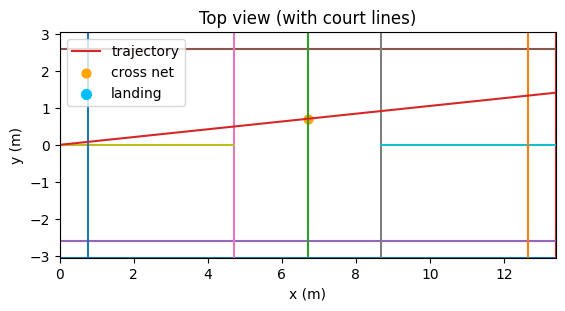

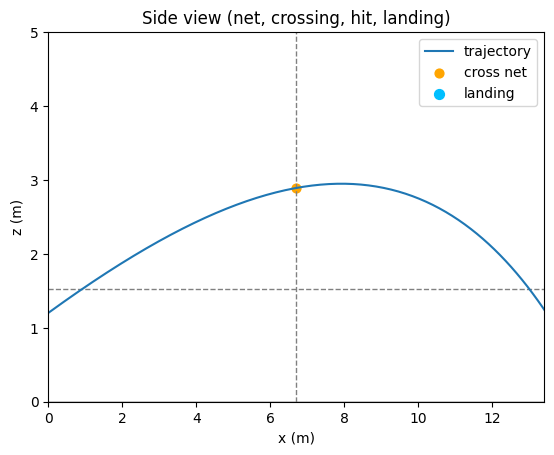

In [13]:
# -*- coding: utf-8 -*-
"""
Badminton 2D visualization (top view x–y & side view x–z) with a minimal physics model.
"""

import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin, radians, sqrt
from dataclasses import dataclass

# ====== Court constants (meters) ======
COURT_LEN = 13.4
COURT_W = 6.1
HALF_W = COURT_W / 2
NET_X = 6.7
NET_H = 1.524

SINGLES_W = 5.18
SINGLES_HALF_W = SINGLES_W / 2  # 2.59 m

# Service lines
SHORT_SERVICE_FROM_NET = 1.98
SHORT_NEAR = NET_X - SHORT_SERVICE_FROM_NET  # 4.72
SHORT_FAR = NET_X + SHORT_SERVICE_FROM_NET   # 8.68

# Doubles long service lines (0.76 m from each back boundary)
DOUBLES_LONG_FROM_BACK = 0.76
LONG_NEAR = DOUBLES_LONG_FROM_BACK            # 0.76
LONG_FAR = COURT_LEN - DOUBLES_LONG_FROM_BACK # 12.64

# ====== Simulation ======
@dataclass
class Params:
    speed_mps: float = 23.0
    yaw_deg: float = 6.0
    pitch_deg: float = 20.0
    drag_k: float = 0.08
    release_height: float = 1.2
    dt: float = 0.01
    max_t: float = 3.0

def simulate_trajectory(p: Params):
    g = 9.81
    yaw = radians(p.yaw_deg)
    pitch = radians(p.pitch_deg)

    vx = p.speed_mps * cos(pitch) * cos(yaw)
    vy = p.speed_mps * cos(pitch) * sin(yaw)
    vz = p.speed_mps * sin(pitch)

    x, y, z = 0.0, 0.0, p.release_height
    pts = []
    apex = {"x": x, "y": y, "z": z, "t": 0.0}
    cross_net = None
    landing = None
    hit_net = None  # 【新增】撞網事件（若發生）
    t = 0.0

    def lerp(a, b, w):  # 線性內插
        return a + w*(b - a)

    prev = None
    while t <= p.max_t and z >= 0.0:
        pts.append((x, y, z, vx, vy, vz, t))
        if z > apex["z"]:
            apex = {"x": x, "y": y, "z": z, "t": t}
        prev = (x, y, z, vx, vy, vz, t)

        # ---- 力學更新（Euler）----
        vmag = sqrt(vx*vx + vy*vy + vz*vz)
        ax = -p.drag_k * vmag * vx
        ay = -p.drag_k * vmag * vy
        az = -g - p.drag_k * vmag * vz

        vx += ax * p.dt
        vy += ay * p.dt
        vz += az * p.dt
        x  += vx * p.dt
        y  += vy * p.dt
        z  += vz * p.dt
        t  += p.dt

        # ---- 同步判斷「網面 x=NET_X」與「地面 z=0」兩個面 ----
        w_net = None
        if (prev[0] - NET_X) * (x - NET_X) <= 0 and x != prev[0]:
            w_net = (NET_X - prev[0]) / (x - prev[0])

        w_land = None
        if prev[2] >= 0.0 and z < 0.0 and z != prev[2]:
            w_land = (0.0 - prev[2]) / (z - prev[2])

        # 僅接受 0~1
        if w_net is not None and not (0.0 <= w_net <= 1.0):
            w_net = None
        if w_land is not None and not (0.0 <= w_land <= 1.0):
            w_land = None

        # 先把交點可用的數值函式化
        def net_point():
            y_net = lerp(prev[1], y, w_net)
            z_net = lerp(prev[2], z, w_net)
            t_net = lerp(prev[6], t, w_net)
            vx_net = lerp(prev[3], vx, w_net)
            vy_net = lerp(prev[4], vy, w_net)
            vz_net = lerp(prev[5], vz, w_net)
            return y_net, z_net, t_net, vx_net, vy_net, vz_net

        def land_point():
            x_land = lerp(prev[0], x, w_land)
            y_land = lerp(prev[1], y, w_land)
            t_land = lerp(prev[6], t, w_land)
            vx_land = lerp(prev[3], vx, w_land)
            vy_land = lerp(prev[4], vy, w_land)
            vz_land = lerp(prev[5], vz, w_land)
            return x_land, y_land, t_land, vx_land, vy_land, vz_land

        # ---- 事件先後（同一步可能同時命中兩面 → 比較 w）----
        if w_net is not None and w_land is not None:
            if w_land <= w_net:
                # 先落地 → 只記落地，結束
                x_land, y_land, t_land, vx_land, vy_land, vz_land = land_point()
                landing = {"x": x_land, "y": y_land, "z": 0.0, "t": t_land}
                pts.append((x_land, y_land, 0.0, vx_land, vy_land, vz_land, t_land))
                break
            else:
                # 先到網面 → 判斷過網 or 撞網
                y_net, z_net, t_net, vx_net, vy_net, vz_net = net_point()
                if cross_net is None:
                    cross_net = {"x": NET_X, "y": y_net, "z": z_net,
                                 "clearance": z_net - NET_H, "t": t_net}
                # 在網面高度以內且 y 在網寬範圍 → 撞網，結束
                if (z_net <= NET_H) and (abs(y_net) <= HALF_W) and (z_net >= 0.0):
                    hit_net = {"x": NET_X, "y": y_net, "z": z_net, "t": t_net}
                    pts.append((NET_X, y_net, z_net, vx_net, vy_net, vz_net, t_net))
                    break
                # 否則只是過網 → 繼續下一步

        elif w_land is not None:
            # 只落地
            x_land, y_land, t_land, vx_land, vy_land, vz_land = land_point()
            landing = {"x": x_land, "y": y_land, "z": 0.0, "t": t_land}
            pts.append((x_land, y_land, 0.0, vx_land, vy_land, vz_land, t_land))
            break

        elif w_net is not None:
            # 只到網面
            y_net, z_net, t_net, vx_net, vy_net, vz_net = net_point()
            if cross_net is None:
                cross_net = {"x": NET_X, "y": y_net, "z": z_net,
                             "clearance": z_net - NET_H, "t": t_net}
            if (z_net <= NET_H) and (abs(y_net) <= HALF_W) and (z_net >= 0.0):
                hit_net = {"x": NET_X, "y": y_net, "z": z_net, "t": t_net}
                pts.append((NET_X, y_net, z_net, vx_net, vy_net, vz_net, t_net))
                break
        # 兩者皆無 → 繼續 while

    points = np.array(pts)
    return {"points": points, "apex": apex, "cross_net": cross_net,
            "landing": landing, "hit_net": hit_net}  # 【新增回傳 hit_net】


# ====== Drawing helpers ======
def draw_court_top(ax):
    """Draw standard badminton court lines in top view (x,y)."""
    # outer doubles boundary
    ax.plot([0, COURT_LEN], [-HALF_W, -HALF_W])
    ax.plot([0, COURT_LEN], [HALF_W, HALF_W])
    ax.plot([0, 0], [-HALF_W, HALF_W])
    ax.plot([COURT_LEN, COURT_LEN], [-HALF_W, HALF_W])

    # singles sidelines
    ax.plot([0, COURT_LEN], [-SINGLES_HALF_W, -SINGLES_HALF_W])
    ax.plot([0, COURT_LEN], [SINGLES_HALF_W, SINGLES_HALF_W])

    # short service lines
    ax.plot([SHORT_NEAR, SHORT_NEAR], [-HALF_W, HALF_W])
    ax.plot([SHORT_FAR, SHORT_FAR], [-HALF_W, HALF_W])

    # center lines
    ax.plot([0, SHORT_NEAR], [0, 0])               
    ax.plot([SHORT_FAR, COURT_LEN], [0, 0])       

    # doubles long service lines
    ax.plot([LONG_NEAR, LONG_NEAR], [-HALF_W, HALF_W])
    ax.plot([LONG_FAR, LONG_FAR], [-HALF_W, HALF_W])

    # net
    ax.plot([NET_X, NET_X], [-HALF_W, HALF_W])

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(0, COURT_LEN)
    ax.set_ylim(-HALF_W, HALF_W)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title("Top view (with court lines)")

def draw_top_view(result):
    """Top view: x–y trajectory and landing."""
    pts = result["points"]
    fig = plt.figure()
    ax = fig.add_subplot(111)
    draw_court_top(ax)

    ax.plot(pts[:,0], pts[:,1], label="trajectory")          # 【修改】加 label

    # 撞網（若有）【新增：整塊】
    if result.get("hit_net"):
        hn = result["hit_net"]
        ax.scatter([hn["x"]], [hn["y"]], c="red", s=60, marker="x", label="hit net")

    # 過網點（若有）【新增：整塊】
    if result["cross_net"] is not None:
        ax.scatter([result["cross_net"]["x"]], [result["cross_net"]["y"]],
                   c="orange", s=40, label="cross net")

    # 落地（若有）【修改】加顏色/大小/label
    if result["landing"] is not None:
        ax.scatter([result["landing"]["x"]], [result["landing"]["y"]],
                   c="deepskyblue", s=50, label="landing")

    ax.legend(loc="best")                                    # 【新增】圖例
    plt.show()


def draw_side_view(result):
    """Side view: x–z trajectory with net reference."""
    pts = result["points"]
    fig = plt.figure()
    ax = fig.add_subplot(111)

    ax.axhline(0.0, color="k", linewidth=1)                 # ground
    ax.axhline(NET_H, color="gray", linestyle="--", linewidth=1)  # net height  【修改】加上樣式
    ax.axvline(NET_X, color="gray", linestyle="--", linewidth=1)  # net position 【修改】加上樣式

    ax.plot(pts[:,0], pts[:,2], label="trajectory")         # 【新增】加 label 以便 legend

    # 過網點（若有）
    if result["cross_net"] is not None:
        ax.scatter([result["cross_net"]["x"]], [result["cross_net"]["z"]],
                   c="orange", s=40, label="cross net")     # 【新增】顏色/大小/label

    # 撞網（若有）【新增：整塊】
    if result.get("hit_net"):
        hn = result["hit_net"]
        ax.scatter([hn["x"]], [hn["z"]], c="red", s=60, marker="x", label="hit net")

    # 落地（若有）：把 z 稍抬高避免與地面重疊【新增：整塊】
    if result["landing"] is not None:
        ax.scatter([result["landing"]["x"]], [0.03], c="deepskyblue", s=50, label="landing")

    ax.set_xlim(0, COURT_LEN)
    ax.set_ylim(0, max(5, float(np.nanmax(pts[:,2]))*1.1))
    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")
    ax.set_title("Side view (net, crossing, hit, landing)") # 【修改】更新標題
    ax.legend(loc="upper right")                             # 【新增】圖例
    plt.show()


# ====== Demo run ======
if __name__ == "__main__":
    p = Params()
    res = simulate_trajectory(p)
    draw_top_view(res)
    draw_side_view(res)
